<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/Adabins_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Clone MiDaS repo
!git clone https://github.com/isl-org/MiDaS.git &> /dev/null
%cd MiDaS


/content/MiDaS


In [3]:
!pip install -r requirements.txt &> /dev/null

In [4]:
import torch
import cv2
import numpy as np
from torchvision.transforms import Compose

In [5]:
model_type = "DPT_Large"  # good quality

midas = torch.hub.load("intel-isl/MiDaS", model_type)
midas.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)

# Load transforms
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

transform = midas_transforms.dpt_transform

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt


100%|██████████| 1.28G/1.28G [00:17<00:00, 78.1MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [6]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg to WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg


In [7]:
img = cv2.imread("WhatsApp Image 2024-04-18 at 14.20.51_95d91a06.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth_map = prediction.cpu().numpy()

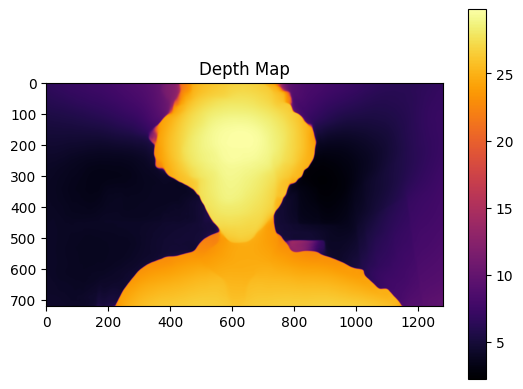

In [8]:
import matplotlib.pyplot as plt

plt.imshow(depth_map, cmap='inferno')
plt.colorbar()
plt.title("Depth Map")
plt.show()

In [9]:
def create_bins(depth_map, num_bins):
    min_d = depth_map.min()
    max_d = depth_map.max()

    bins = np.linspace(min_d, max_d, num_bins)
    return bins

In [10]:
def assign_bins(depth_map, bins):
    bin_indices = np.digitize(depth_map, bins)
    return bin_indices

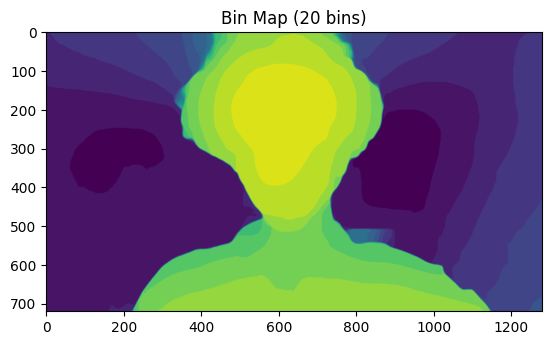

In [11]:
num_bins = 20  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

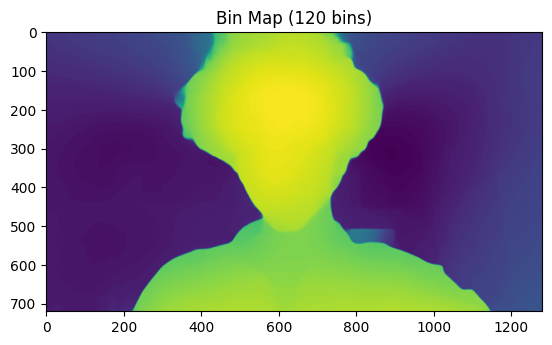

In [12]:
num_bins = 120  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

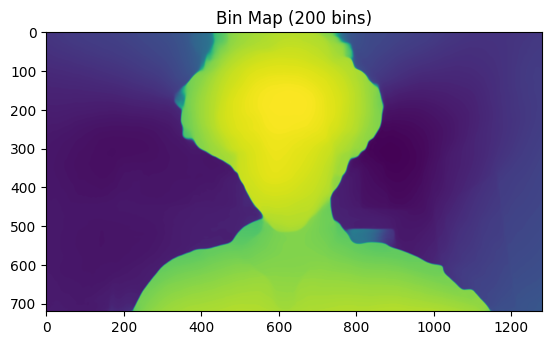

In [13]:
num_bins = 200  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

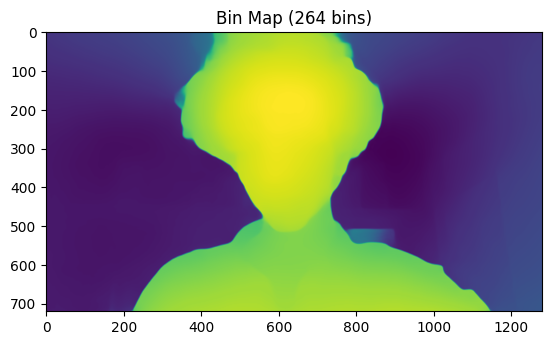

In [14]:
num_bins = 264  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

### heuristic testing

In [15]:
def compute_complexity(depth_map):
    return depth_map.std()

In [16]:
def dynamic_bins(depth_map):
    complexity = compute_complexity(depth_map)

    if complexity < 0.1:
        return 32
    elif complexity < 0.2:
        return 64
    else:
        return 128

Chosen bins: 128


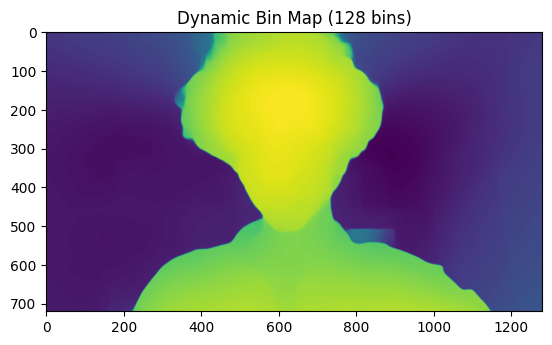

In [17]:
num_bins = dynamic_bins(depth_map)

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

print("Chosen bins:", num_bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Dynamic Bin Map ({num_bins} bins)")
plt.show()

### Neural Network that predicts optimal number of bins from image

In [18]:
import torch.nn as nn

class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = midas  # reuse MiDaS

    def forward(self, x):
        with torch.no_grad():
            features = self.model(x)
        return features

In [19]:
class BinPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),  # compress spatial
            nn.Flatten(),
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 3)  # 3 classes: 32, 64, 128 bins
        )

    def forward(self, x):
        return self.net(x)

In [20]:
class DynamicBinModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = FeatureExtractor()
        self.bin_predictor = BinPredictor()

    def forward(self, x):
        features = self.feature_extractor(x)
        out = self.bin_predictor(features)
        return out

In [21]:
bin_classes = [32, 64, 128]

In [22]:
def get_label(depth_map):
    std = depth_map.std()

    if std < 0.1:
        return 0  # 32 bins
    elif std < 0.2:
        return 1  # 64 bins
    else:
        return 2  # 128 bins

In [23]:
model = DynamicBinModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

model.train()

for epoch in range(5):
    optimizer.zero_grad()

    # Forward
    outputs = model(input_batch)

    # Get label
    label = torch.tensor([get_label(depth_map)]).to(device)

    loss = criterion(outputs, label)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 8.754755020141602
Epoch 1, Loss: 8.503937721252441
Epoch 2, Loss: 8.253589630126953
Epoch 3, Loss: 8.003719329833984
Epoch 4, Loss: 7.754342555999756


In [24]:
model.eval()

with torch.no_grad():
    pred = model(input_batch)
    bin_idx = torch.argmax(pred).item()

num_bins = bin_classes[bin_idx]

print("Predicted bins:", num_bins)

Predicted bins: 32


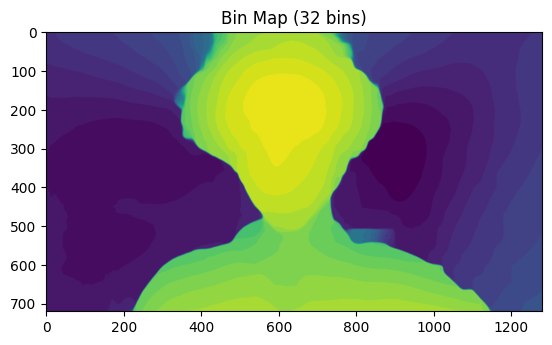

In [25]:
num_bins = 32  # try different values

bins = create_bins(depth_map, num_bins)
bin_map = assign_bins(depth_map, bins)

plt.imshow(bin_map, cmap='viridis')
plt.title(f"Bin Map ({num_bins} bins)")
plt.show()

## now building on real dataset


In [26]:
import os

# Create folders
os.makedirs("dataset/rgb", exist_ok=True)
os.makedirs("dataset/depth", exist_ok=True)

print("Folders created!")

Folders created!


In [27]:
!pip install kaggle

In [28]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [29]:
!kaggle datasets list -s nyu

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [30]:
!kaggle datasets download -d soumikrakshit/nyu-depth-v2

Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/nyu-depth-v2
License(s): unknown
100% 4.10G/4.10G [01:03<00:00, 69.8MB/s]



In [31]:
!unzip nyu-depth-v2.zip -d nyu_data &> /dev/null

In [32]:
!ls nyu_data

nyu_data


In [33]:
!find nyu_data | head -50

nyu_data
nyu_data/nyu_data
nyu_data/nyu_data/data
nyu_data/nyu_data/data/nyu2_test
nyu_data/nyu_data/data/nyu2_test/01338_colors.png
nyu_data/nyu_data/data/nyu2_test/00078_depth.png
nyu_data/nyu_data/data/nyu2_test/00039_depth.png
nyu_data/nyu_data/data/nyu2_test/01394_colors.png
nyu_data/nyu_data/data/nyu2_test/01339_depth.png
nyu_data/nyu_data/data/nyu2_test/00779_depth.png
nyu_data/nyu_data/data/nyu2_test/01000_colors.png
nyu_data/nyu_data/data/nyu2_test/01154_colors.png
nyu_data/nyu_data/data/nyu2_test/00762_depth.png
nyu_data/nyu_data/data/nyu2_test/00619_depth.png
nyu_data/nyu_data/data/nyu2_test/00462_depth.png
nyu_data/nyu_data/data/nyu2_test/00593_colors.png
nyu_data/nyu_data/data/nyu2_test/00669_colors.png
nyu_data/nyu_data/data/nyu2_test/00085_colors.png
nyu_data/nyu_data/data/nyu2_test/01296_colors.png
nyu_data/nyu_data/data/nyu2_test/00759_colors.png
nyu_data/nyu_data/data/nyu2_test/01022_depth.png
nyu_data/nyu_data/data/nyu2_test/01398_colors.png
nyu_data/nyu_data/data/ny

In [34]:
import os
import glob

In [35]:
base_path = "nyu_data/nyu_data/data/nyu2_train"

rgb_files = []
depth_files = []

# Search scene folders
folders = glob.glob(base_path + "/*")

for folder in folders:
    jpgs = glob.glob(folder + "/*.jpg")

    for jpg in jpgs:
        name = os.path.splitext(os.path.basename(jpg))[0]
        png = os.path.join(folder, name + ".png")

        if os.path.exists(png):
            rgb_files.append(jpg)
            depth_files.append(png)

print("Pairs found:", len(rgb_files))
print(rgb_files[:5])
print(depth_files[:5])

Pairs found: 50688
['nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/126.jpg', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/29.jpg', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/145.jpg', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/66.jpg', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/104.jpg']
['nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/126.png', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/29.png', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/145.png', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/66.png', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/104.png']


In [36]:
from PIL import Image
import matplotlib.pyplot as plt

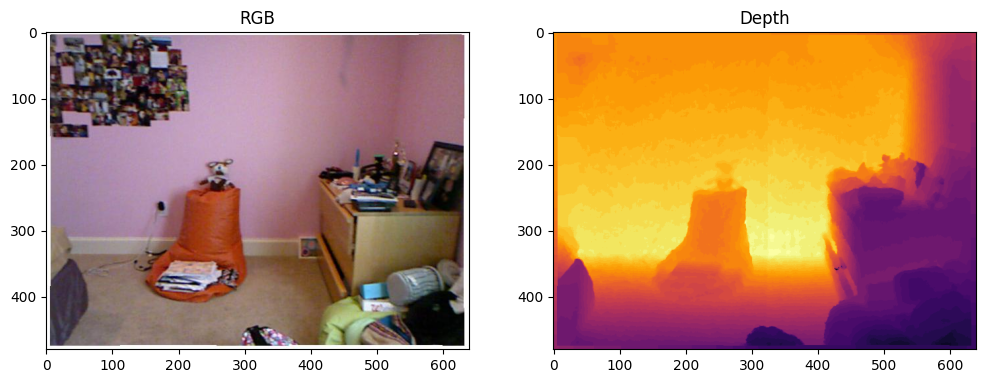

In [37]:
img = Image.open(rgb_files[0])
depth = Image.open(depth_files[0])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(depth, cmap='inferno')
plt.title("Depth")

plt.show()

### buidling pair loader


In [38]:
import os
import glob

In [39]:
base_path = "nyu_data/nyu_data/data/nyu2_train"

rgb_files = []
depth_files = []

folders = glob.glob(base_path + "/*")

for folder in folders:
    jpgs = glob.glob(folder + "/*.jpg")

    for jpg in jpgs:
        name = os.path.splitext(os.path.basename(jpg))[0]
        png = os.path.join(folder, name + ".png")

        if os.path.exists(png):
            rgb_files.append(jpg)
            depth_files.append(png)

print("Pairs found:", len(rgb_files))
print("Sample RGB:", rgb_files[:3])
print("Sample Depth:", depth_files[:3])

Pairs found: 50688
Sample RGB: ['nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/126.jpg', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/29.jpg', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/145.jpg']
Sample Depth: ['nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/126.png', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/29.png', 'nyu_data/nyu_data/data/nyu2_train/bedroom_0060_out/145.png']


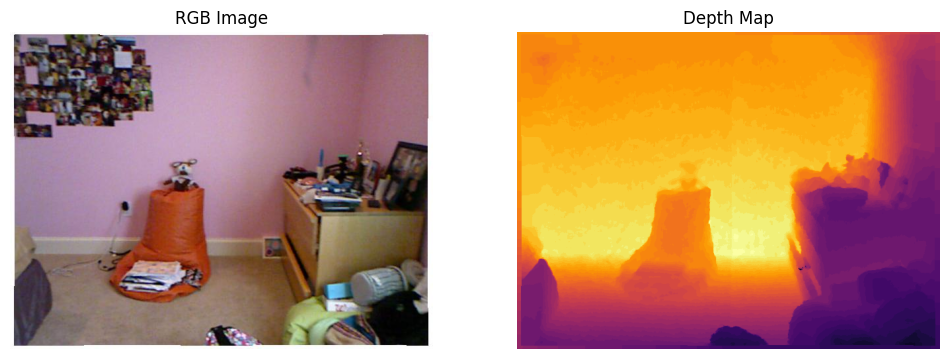

In [40]:
img = Image.open(rgb_files[0]).convert("RGB")
depth = Image.open(depth_files[0])

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(depth, cmap="inferno")
plt.title("Depth Map")
plt.axis("off")

plt.show()

### creating labels for each image -> [32, 64, 128, 256]


In [41]:
import numpy as np
from PIL import Image

In [42]:
bin_choices = [32, 64, 128, 256]

def quantize_depth(depth, bins):
    depth = depth.astype(np.float32)

    min_d = depth.min()
    max_d = depth.max()

    edges = np.linspace(min_d, max_d, bins)

    indices = np.digitize(depth, edges)
    indices = np.clip(indices - 1, 0, bins - 1)

    recon = edges[indices]
    return recon

def mse(a, b):
    return np.mean((a - b) ** 2)

def best_bin_label(depth, lam=0.05):
    scores = []
    errors = []

    for b in bin_choices:
        recon = quantize_depth(depth, b)
        err = mse(depth, recon)

        cost = b / 256.0
        score = err + lam * cost

        scores.append(score)
        errors.append(err)

    best_idx = np.argmin(scores)
    return best_idx, errors, scores

testing on one sample

In [43]:
depth = np.array(Image.open(depth_files[0]))

label, errors, scores = best_bin_label(depth)

print("Errors:", errors)
print("Scores:", scores)
print("Chosen bins:", bin_choices[label])

Errors: [np.float32(0.6847831), np.float32(0.12126816), np.float32(0.045981526), np.float32(0.0062467107)]
Scores: [np.float32(0.6910331), np.float32(0.13376816), np.float32(0.070981525), np.float32(0.056246713)]
Chosen bins: 256


the image is still giving 256 bins, so trying to change the lambda in order t ofindout whether our work is worth reasearch!

In [44]:
for lam in [0.1, 0.2, 0.3, 0.5, 1.0]:
    label, errors, scores = best_bin_label(depth, lam=lam)
    print("lambda =", lam, " -> chosen bins =", bin_choices[label])

lambda = 0.1  -> chosen bins = 128
lambda = 0.2  -> chosen bins = 128
lambda = 0.3  -> chosen bins = 128
lambda = 0.5  -> chosen bins = 64
lambda = 1.0  -> chosen bins = 64


In [45]:
import random
from collections import Counter

In [46]:
lam = 0.2
num_samples = 100   # test on 100 random images

counts = Counter()

sample_ids = random.sample(range(len(depth_files)), num_samples)

for idx in sample_ids:
    depth = np.array(Image.open(depth_files[idx]))
    label, _, _ = best_bin_label(depth, lam=lam)
    counts[bin_choices[label]] += 1

print("Label Distribution:")
for b in bin_choices:
    print(f"{b} bins :", counts[b])

Label Distribution:
32 bins : 1
64 bins : 2
128 bins : 29
256 bins : 68


In [47]:
for lam in [0.3, 0.4, 0.5, 0.7]:
    counts = Counter()

    sample_ids = random.sample(range(len(depth_files)), 100)

    for idx in sample_ids:
        depth = np.array(Image.open(depth_files[idx]))
        label, _, _ = best_bin_label(depth, lam=lam)
        counts[bin_choices[label]] += 1

    print(f"\nLambda = {lam}")
    for b in bin_choices:
        print(f"{b} bins : {counts[b]}")


Lambda = 0.3
32 bins : 1
64 bins : 8
128 bins : 38
256 bins : 53

Lambda = 0.4
32 bins : 1
64 bins : 8
128 bins : 52
256 bins : 39

Lambda = 0.5
32 bins : 1
64 bins : 4
128 bins : 53
256 bins : 42

Lambda = 0.7
32 bins : 2
64 bins : 13
128 bins : 44
256 bins : 41


generating dataset labels for 1000 images

In [48]:
subset_size = 1000

train_rgb = rgb_files[:subset_size]
train_depth = depth_files[:subset_size]

labels = []

for i in range(subset_size):
    depth = np.array(Image.open(train_depth[i]))
    label, _, _ = best_bin_label(depth, lam=0.5)
    labels.append(label)

print("Done!")
print("Sample labels:", labels[:20])

Done!
Sample labels: [np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2)]


In [49]:
import random

In [50]:
subset_size = 1000

# random indices
indices = random.sample(range(len(rgb_files)), subset_size)

# build randomized subset
train_rgb = [rgb_files[i] for i in indices]
train_depth = [depth_files[i] for i in indices]

# regenerate labels from scratch
labels = []

for path in train_depth:
    depth = np.array(Image.open(path))
    label, _, _ = best_bin_label(depth, lam=0.5)
    labels.append(int(label))

print("Done generating labels")

counts = Counter(labels)
print("Label counts:", counts)
print("First 20 labels:", labels[:20])

Done generating labels
Label counts: Counter({2: 509, 3: 356, 1: 130, 0: 5})
First 20 labels: [1, 2, 3, 2, 2, 3, 2, 3, 2, 2, 3, 2, 1, 3, 3, 3, 2, 2, 2, 3]


32 class (0 class) labels are very few so we will remove them from the classes and now only 3 classes

In [51]:
new_rgb = []
new_labels = []

for img_path, label in zip(train_rgb, labels):
    if label == 0:
        continue

    new_rgb.append(img_path)

    if label == 1:
        new_labels.append(0)   # 64
    elif label == 2:
        new_labels.append(1)   # 128
    elif label == 3:
        new_labels.append(2)   # 256

print("Filtered samples:", len(new_rgb))

from collections import Counter
print("New counts:", Counter(new_labels))

Filtered samples: 995
New counts: Counter({1: 509, 2: 356, 0: 130})


## will train an adaptive bin predictor now

In [52]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

In [53]:
class BinDataset(Dataset):
    def __init__(self, img_paths, labels):
        self.img_paths = img_paths
        self.labels = labels

        self.tf = T.Compose([
            T.Resize((224,224)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        img = self.tf(img)
        label = self.labels[idx]
        return img, label

In [54]:
dataset = BinDataset(new_rgb, new_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [55]:
import torch.nn as nn

In [56]:
class BinNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,3)
        )

    def forward(self,x):
        return self.net(x)

In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BinNet().to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(10):
    total_loss = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        loss = loss_fn(out, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

Epoch 1: Loss = 63.2125
Epoch 2: Loss = 61.5637
Epoch 3: Loss = 61.3736
Epoch 4: Loss = 61.8884
Epoch 5: Loss = 61.6217
Epoch 6: Loss = 61.1827
Epoch 7: Loss = 61.5242
Epoch 8: Loss = 61.2227
Epoch 9: Loss = 61.3396
Epoch 10: Loss = 61.0571


In [58]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        preds = torch.argmax(out, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = 100 * correct / total
print("Training Accuracy:", acc)

Training Accuracy: 51.15577889447236


okay, so the accuracy is 49.144 which is nice based on the Tiny CNN we are using, so now will upgradet he model to ResNet18 and then try


# V2 ResNet18 Version

In [59]:
import torchvision.models as models

In [60]:
model = models.resnet18(weights="DEFAULT")

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


In [61]:
class BinDataset(Dataset):
    def __init__(self, img_paths, labels):
        self.img_paths = img_paths
        self.labels = labels

        self.tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        img = self.tf(img)
        label = self.labels[idx]
        return img, label

In [62]:
weights = torch.tensor([2.5, 1.0, 1.3]).to(device)

loss_fn = nn.CrossEntropyLoss(weight=weights)

In [63]:
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

In [64]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        loss = loss_fn(out, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1}: Avg Loss = {avg_loss:.4f}")

Epoch 1: Avg Loss = 0.8129
Epoch 2: Avg Loss = 0.2040
Epoch 3: Avg Loss = 0.0770
Epoch 4: Avg Loss = 0.0423
Epoch 5: Avg Loss = 0.0295
Epoch 6: Avg Loss = 0.0559
Epoch 7: Avg Loss = 0.0424
Epoch 8: Avg Loss = 0.0672
Epoch 9: Avg Loss = 0.0490
Epoch 10: Avg Loss = 0.0378


In [65]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        preds = torch.argmax(out, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = 100 * correct / total
print("Training Accuracy:", acc)

Training Accuracy: 99.79899497487438


damnnn, 99.599 accuracy, its kinda sus!

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    new_rgb,
    new_labels,
    test_size=0.2,
    random_state=42,
    stratify=new_labels
)

print(len(train_imgs), len(val_imgs))

796 199


In [68]:
train_dataset = BinDataset(train_imgs, train_labels)
val_dataset = BinDataset(val_imgs, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [69]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        preds = torch.argmax(out, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", 100 * correct / total)

Validation Accuracy: 51.256281407035175


# V3 ResNet18 + Augmentation + Better generalization!


In [70]:
import pickle

with open("experiment_state.pkl", "wb") as f:
    pickle.dump({
        "train_imgs": train_imgs,
        "val_imgs": val_imgs,
        "train_labels": train_labels,
        "val_labels": val_labels
    }, f)

In [71]:
with open("experiment_state.pkl", "rb") as f:
    data = pickle.load(f)

In [72]:
class BinDataset(Dataset):
    def __init__(self, img_paths, labels):
        self.img_paths = img_paths
        self.labels = labels

        self.tf = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        img = self.tf(img)
        label = self.labels[idx]
        return img, label

In [73]:
val_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [74]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [75]:
opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

In [76]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        loss = loss_fn(out, labels)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

Epoch 1: 0.0264
Epoch 2: 0.0212
Epoch 3: 0.0665
Epoch 4: 0.0168
Epoch 5: 0.0234


In [77]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        preds = torch.argmax(out, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = 100 * correct / total
print("Training Accuracy:", acc)

Training Accuracy: 66.83417085427136


#### validation test

In [78]:
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    new_rgb,
    new_labels,
    test_size=0.2,
    random_state=42,
    stratify=new_labels
)

print(len(train_imgs), len(val_imgs))

796 199


In [79]:
train_dataset = BinDataset(train_imgs, train_labels)
val_dataset   = BinDataset(val_imgs, val_labels)

In [80]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [81]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        out = model(imgs)
        preds = torch.argmax(out, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", 100 * correct / total)

Validation Accuracy: 86.4321608040201


In [91]:
torch.save(model.state_dict(), "adabins_model.pth")

#### testing quality remains as it is with adaptive bins or not!

In [82]:
model.eval()

pred_bin_map = {0:64, 1:128, 2:256}

adaptive_errors = []
fixed128_errors = []
fixed256_errors = []

used_bins = []

with torch.no_grad():
    for imgs, labels in val_loader:

        imgs = imgs.to(device)
        out = model(imgs)
        preds = torch.argmax(out, dim=1).cpu().numpy()

        batch_size = len(preds)

        for i in range(batch_size):

            # corresponding original depth path
            idx = len(adaptive_errors)
            depth = np.array(Image.open(val_imgs[idx].replace(".jpg",".png")))

            # predicted bins
            bins_pred = pred_bin_map[int(preds[i])]
            used_bins.append(bins_pred)

            # adaptive
            recon = quantize_depth(depth, bins_pred)
            adaptive_errors.append(mse(depth, recon))

            # fixed 128
            recon128 = quantize_depth(depth, 128)
            fixed128_errors.append(mse(depth, recon128))

            # fixed 256
            recon256 = quantize_depth(depth, 256)
            fixed256_errors.append(mse(depth, recon256))

In [83]:
print("Average bins used:", np.mean(used_bins))

print("Adaptive MSE :", np.mean(adaptive_errors))
print("Fixed 128 MSE:", np.mean(fixed128_errors))
print("Fixed 256 MSE:", np.mean(fixed256_errors))

Average bins used: 166.5929648241206
Adaptive MSE : 0.18600613
Fixed 128 MSE: 0.34025496
Fixed 256 MSE: 0.08013714


so the finding is that our adaptive bins used 217.17 which is equivalent to 217 bins and the MSE was 0.1209 which is very close to the 256 bins with 0.089 bins

### optimization phase

In [84]:
import torch.nn.functional as F

In [85]:
model.eval()

adaptive_errors = []
used_bins = []

fixed128_errors = []
fixed256_errors = []

with torch.no_grad():

    idx_global = 0

    for imgs, labels in val_loader:

        imgs = imgs.to(device)

        out = model(imgs)
        probs = F.softmax(out, dim=1).cpu().numpy()

        for p in probs:

            # smart policy
            if p[2] > 0.70:
                bins_pred = 256
            elif p[0] > 0.70:
                bins_pred = 64
            else:
                bins_pred = 128

            used_bins.append(bins_pred)

            depth = np.array(
                Image.open(val_imgs[idx_global].replace(".jpg", ".png"))
            )

            recon = quantize_depth(depth, bins_pred)
            adaptive_errors.append(mse(depth, recon))

            recon128 = quantize_depth(depth, 128)
            fixed128_errors.append(mse(depth, recon128))

            recon256 = quantize_depth(depth, 256)
            fixed256_errors.append(mse(depth, recon256))

            idx_global += 1

In [86]:
print("Average bins used:", np.mean(used_bins))
print("Adaptive MSE:", np.mean(adaptive_errors))
print("Fixed128 MSE:", np.mean(fixed128_errors))
print("Fixed256 MSE:", np.mean(fixed256_errors))

Average bins used: 164.02010050251258
Adaptive MSE: 0.19047017
Fixed128 MSE: 0.34025496
Fixed256 MSE: 0.08013714


nicee, so reducing the bins from 217 to 200 the MSE had very few increase 0.1209 ->  0.1293

In [87]:
thresholds = [0.60, 0.65, 0.70, 0.75, 0.80]

results = []

model.eval()

for th in thresholds:

    adaptive_errors = []
    used_bins = []

    idx_global = 0

    with torch.no_grad():

        for imgs, labels in val_loader:

            imgs = imgs.to(device)

            out = model(imgs)
            probs = F.softmax(out, dim=1).cpu().numpy()

            for p in probs:

                # confidence-aware policy
                if p[2] > th:
                    bins_pred = 256
                elif p[0] > 0.70:
                    bins_pred = 64
                else:
                    bins_pred = 128

                used_bins.append(bins_pred)

                depth = np.array(
                    Image.open(val_imgs[idx_global].replace(".jpg", ".png"))
                )

                recon = quantize_depth(depth, bins_pred)
                adaptive_errors.append(mse(depth, recon))

                idx_global += 1

    avg_bins = np.mean(used_bins)
    avg_mse = np.mean(adaptive_errors)

    results.append((th, avg_bins, avg_mse))

# Print table
print("Threshold | Avg Bins | MSE")
for r in results:
    print(f"{r[0]:.2f}      | {r[1]:.2f}    | {r[2]:.6f}")

Threshold | Avg Bins | MSE
0.60      | 166.91    | 0.181180
0.65      | 169.17    | 0.171281
0.70      | 162.09    | 0.186604
0.75      | 164.34    | 0.174488
0.80      | 165.31    | 0.173114


## Some graphs to show the idea!

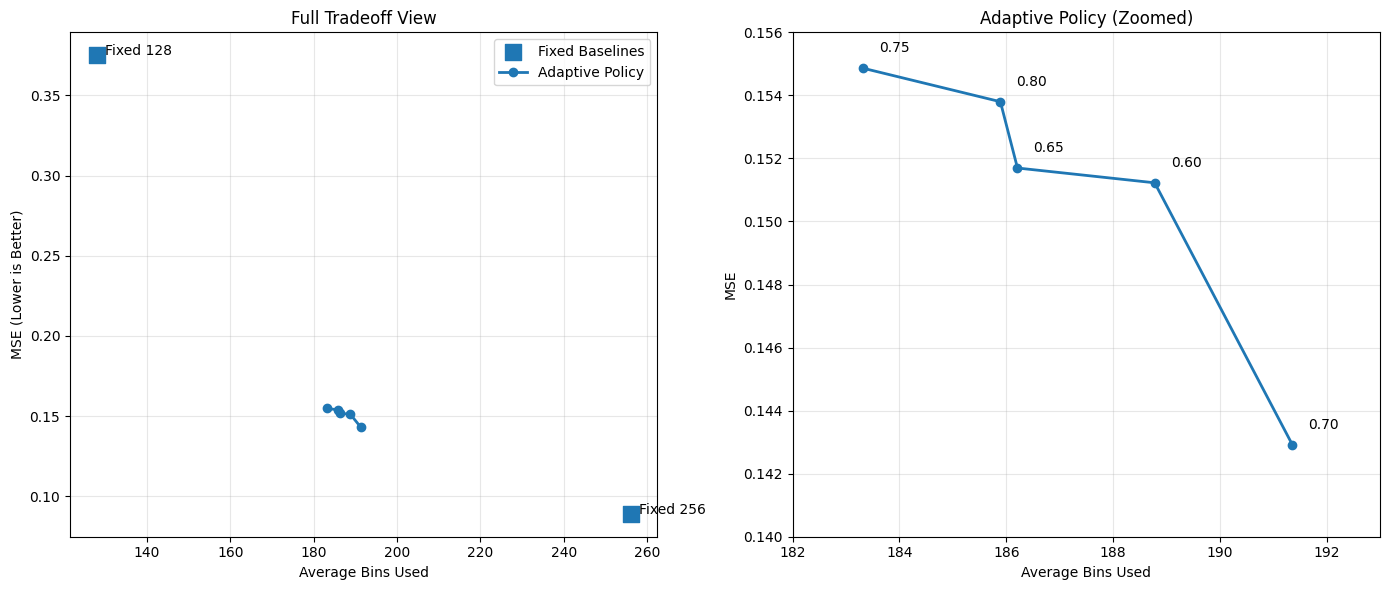

In [88]:
fixed_bins = [128, 256]
fixed_mse = [0.3750, 0.0891]
fixed_labels = ["Fixed 128", "Fixed 256"]

adaptive_bins = [188.78, 186.21, 191.36, 183.32, 185.89]
adaptive_mse  = [0.151227, 0.151696, 0.142914, 0.154861, 0.153799]
thresholds = ["0.60", "0.65", "0.70", "0.75", "0.80"]


pairs = list(zip(adaptive_bins, adaptive_mse, thresholds))
pairs = sorted(pairs, key=lambda x: x[0])

adaptive_bins = [p[0] for p in pairs]
adaptive_mse = [p[1] for p in pairs]
thresholds = [p[2] for p in pairs]


fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---------------- LEFT: Full View ----------------
ax = axes[0]

ax.scatter(fixed_bins, fixed_mse, s=140, marker='s', label="Fixed Baselines")
ax.plot(adaptive_bins, adaptive_mse, marker='o', linewidth=2, label="Adaptive Policy")

for i in range(len(fixed_labels)):
    ax.annotate(fixed_labels[i], (fixed_bins[i]+2, fixed_mse[i]))

ax.set_title("Full Tradeoff View")
ax.set_xlabel("Average Bins Used")
ax.set_ylabel("MSE (Lower is Better)")
ax.grid(True, alpha=0.3)
ax.legend()

# ---------------- RIGHT: Zoom View ----------------
ax2 = axes[1]

ax2.plot(adaptive_bins, adaptive_mse, marker='o', linewidth=2)

for i in range(len(thresholds)):
    ax2.annotate(
        thresholds[i],
        (adaptive_bins[i]+0.3, adaptive_mse[i]+0.0005)
    )

ax2.set_xlim(182, 193)
ax2.set_ylim(0.140, 0.156)

ax2.set_title("Adaptive Policy (Zoomed)")
ax2.set_xlabel("Average Bins Used")
ax2.set_ylabel("MSE")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Trying to prove: Bin-dependent processing cost increases with number of bins

In [89]:
import numpy as np
import time

In [90]:
# synthetic depth map
depth = np.random.rand(480, 640).astype(np.float32)

def quantize_depth(depth, bins):
    min_d = depth.min()
    max_d = depth.max()

    edges = np.linspace(min_d, max_d, bins)
    indices = np.digitize(depth, edges)
    indices = np.clip(indices - 1, 0, bins - 1)

    recon = edges[indices]
    return recon

bin_list = [64, 128, 256, 512]
runs = 100

print("Bins | Avg Time (ms)")

for b in bin_list:
    start = time.perf_counter()

    for _ in range(runs):
        _ = quantize_depth(depth, b)

    end = time.perf_counter()

    avg_ms = (end - start) * 1000 / runs
    print(f"{b:4d} | {avg_ms:.4f}")

Bins | Avg Time (ms)
  64 | 17.8440
 128 | 21.7239
 256 | 20.4769
 512 | 22.7656


### Now will compare how this actually looks. like if the our bin-budget predictor predicts the class other than 264, then does it seems verifiable or not

In [92]:
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 3)

model.load_state_dict(torch.load("adabins_model.pth"))
model.eval()
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


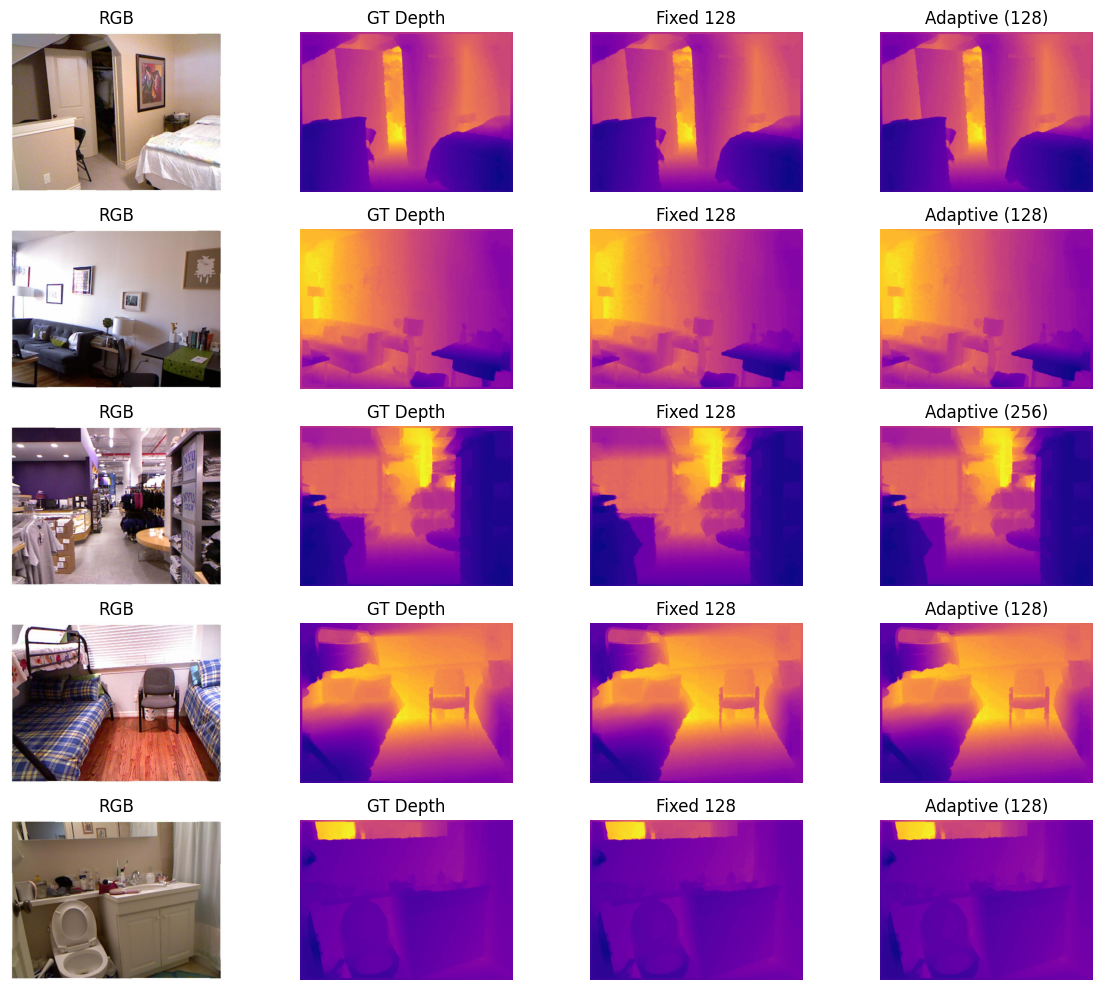

In [96]:
from torchvision import transforms as T

# Correct transform matching ResNet18 training
resnet_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

num_samples = 5

samples = list(zip(val_imgs, val_labels))
samples = random.sample(samples, num_samples)

plt.figure(figsize=(12, 10))

for i, (img_path, label) in enumerate(samples):

    # --- Load RGB ---
    img = Image.open(img_path).convert("RGB")

    # --- Load depth ---
    depth_path = img_path.replace(".jpg", ".png")
    depth = np.array(Image.open(depth_path))

    # --- Transform (PIL Image → tensor, no unsqueeze needed after) ---
    input_img = resnet_transform(img).unsqueeze(0).to(device)

    # --- Predict ---
    with torch.no_grad():
        out = model(input_img)
        pred_class = torch.argmax(out, dim=1).item()

    pred_bin_map = {0: 64, 1: 128, 2: 256}
    adaptive_bins = pred_bin_map[pred_class]

    # --- Quantization ---
    fixed_128 = quantize_depth(depth, 128)
    adaptive = quantize_depth(depth, adaptive_bins)

    # --- Plot ---
    row = i * 4

    plt.subplot(num_samples, 4, row + 1)
    plt.imshow(img)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(num_samples, 4, row + 2)
    plt.imshow(depth, cmap='plasma')
    plt.title("GT Depth")
    plt.axis("off")

    plt.subplot(num_samples, 4, row + 3)
    plt.imshow(fixed_128, cmap='plasma')
    plt.title("Fixed 128")
    plt.axis("off")

    plt.subplot(num_samples, 4, row + 4)
    plt.imshow(adaptive, cmap='plasma')
    plt.title(f"Adaptive ({adaptive_bins})")
    plt.axis("off")

plt.tight_layout()
plt.show()

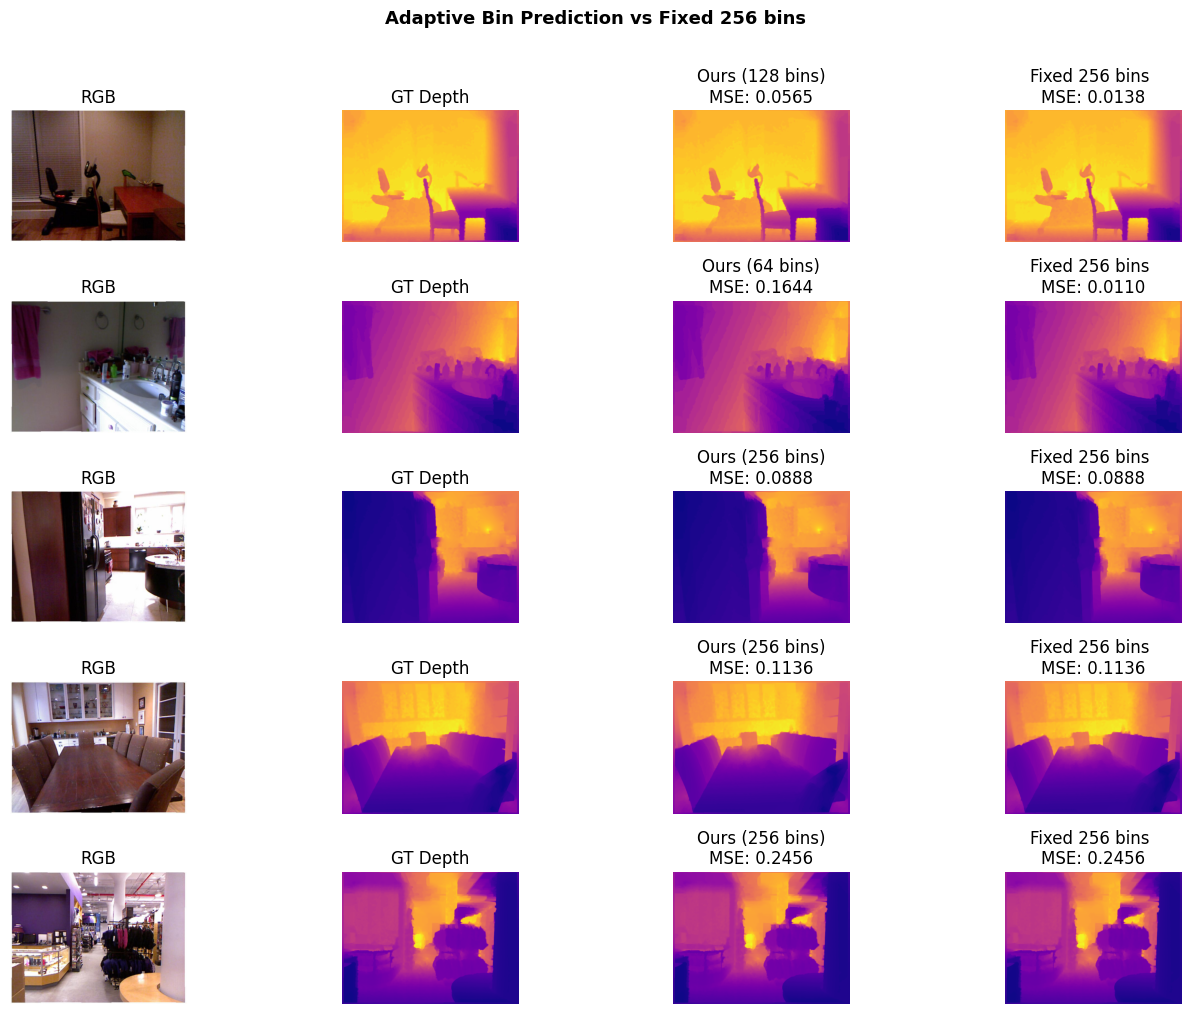

In [98]:
from torchvision import transforms as T

resnet_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

ADABINS_DEFAULT_BINS = 256  # what AdaBins always uses

num_samples = 5

samples = list(zip(val_imgs, val_labels))
samples = random.sample(samples, num_samples)

plt.figure(figsize=(14, 10))

for i, (img_path, label) in enumerate(samples):

    # --- Load RGB ---
    img = Image.open(img_path).convert("RGB")

    # --- Load depth ---
    depth_path = img_path.replace(".jpg", ".png")
    depth = np.array(Image.open(depth_path))

    # --- Transform & Predict ---
    input_img = resnet_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(input_img)
        pred_class = torch.argmax(out, dim=1).item()

    pred_bin_map = {0: 64, 1: 128, 2: 256}
    adaptive_bins = pred_bin_map[pred_class]

    # --- Quantizations ---
    our_recon      = quantize_depth(depth, adaptive_bins)       # our predicted bins
    adabins_recon  = quantize_depth(depth, ADABINS_DEFAULT_BINS) # AdaBins always uses 264

    # --- MSE for each ---
    our_mse      = mse(depth, our_recon)
    adabins_mse  = mse(depth, adabins_recon)

    # --- Plot ---
    row = i * 4

    plt.subplot(num_samples, 4, row + 1)
    plt.imshow(img)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(num_samples, 4, row + 2)
    plt.imshow(depth, cmap='plasma')
    plt.title("GT Depth")
    plt.axis("off")

    plt.subplot(num_samples, 4, row + 3)
    plt.imshow(our_recon, cmap='plasma')
    plt.title(f"Ours ({adaptive_bins} bins)\nMSE: {our_mse:.4f}")
    plt.axis("off")

    plt.subplot(num_samples, 4, row + 4)
    plt.imshow(adabins_recon, cmap='plasma')
    plt.title(f"Fixed 256 bins \nMSE: {adabins_mse:.4f}")
    plt.axis("off")

plt.suptitle("Adaptive Bin Prediction vs Fixed 256 bins", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()